In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("orders_raw.csv")
p = pd.read_csv("products.csv")

print(df.head())
print(p.head())

   order_id  order_date customer_name       city              category  \
0         1  2026-03-09           Dev       Pune    Snacks & Beverages   
1         2  2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3  2026-06-30          Yash  Bengaluru  Household Essentials   
3         4  2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5  2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  
0          13         5       175.0          UPI  Delivered     5.0  
1          15         1        60.0   Debit Card  Delivered     5.0  
2          25         2       150.0          UPI  Delivered     2.0  
3          11         1        30.0          UPI  Delivered     4.0  
4          14         2       220.0   Debit Card  Delivered     3.0  
   product_id   product_name             category             supplier  \
0           1     Banana 1kg  Fruits & Vegetables        Fres

In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(508, 11)
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB
None
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           69
dtype: int64
8


In [5]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))



Rows after removing duplicates: 500


In [6]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

print(df["city"].unique())
print(df["category"].unique())

<StringArray>
['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
<StringArray>
[  'Snacks & Beverages', 'Household Essentials',               'Bakery',
        'Personal Care',  'Fruits & Vegetables',         'Dairy & Eggs']
Length: 6, dtype: str


In [7]:
print(df["amount_inr"].isnull().sum())
print(df["amount_inr"].describe())

10
count     490.000000
mean      257.132653
std       563.408957
min        20.000000
25%        90.000000
50%       166.500000
75%       280.000000
max      7600.000000
Name: amount_inr, dtype: float64


In [8]:
df["amount_inr"] = df["amount_inr"].fillna(df["amount_inr"].median())

print("Missing values:", df["amount_inr"].isnull().sum())

Missing values: 0


In [9]:
q1 = df["amount_inr"].quantile(0.25)
q3 = df["amount_inr"].quantile(0.75)

iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

print("Lower limit:", low)
print("Upper limit:", high)

print(df[df["amount_inr"] > high][["order_id", "amount_inr"]])

Lower limit: -195.0
Upper limit: 565.0
     order_id  amount_inr
76         77       650.0
78         79       600.0
120       121       580.0
130       131       580.0
138       139       580.0
151       152       720.0
172       173      4800.0
192       193       600.0
196       197       600.0
198       199      5400.0
213       214      1100.0
221       222       660.0
233       234       650.0
249       250      5200.0
255       256      4400.0
322       323      7600.0
333       334       720.0
336       337       600.0
395       396       900.0
432       433       600.0
486       487       650.0


In [10]:
df = df[df["amount_inr"] < 2000]

print("Rows after removing outliers:", len(df))

Rows after removing outliers: 495


In [11]:
print("Current rows:", len(df))
print("Duplicates:", df.duplicated().sum())
print("Values >= 2000:", (df["amount_inr"] >= 2000).sum())

Current rows: 495
Duplicates: 0
Values >= 2000: 0


In [12]:
print(df.isnull().sum())

order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr        0
payment_mode      0
status            0
rating           64
dtype: int64


In [13]:
print(df["amount_inr"].describe())


count     495.000000
mean      202.545455
std       150.777635
min        20.000000
25%        90.000000
50%       166.500000
75%       275.000000
max      1100.000000
Name: amount_inr, dtype: float64


In [14]:
df = df.merge(p, on="product_id", how="left")

print(df.head())
print(df.columns)

   order_id  order_date customer_name       city            category_x  \
0         1  2026-03-09           Dev       Pune    Snacks & Beverages   
1         2  2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3  2026-06-30          Yash  Bengaluru  Household Essentials   
3         4  2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5  2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  \
0          13         5       175.0          UPI  Delivered     5.0   
1          15         1        60.0   Debit Card  Delivered     5.0   
2          25         2       150.0          UPI  Delivered     2.0   
3          11         1        30.0          UPI  Delivered     4.0   
4          14         2       220.0   Debit Card  Delivered     3.0   

          product_name            category_y                supplier  \
0         Biscuit Pack    Snacks & Beverages      BakeHo

In [15]:
print("Missing categories:", df["category"].isnull().sum())
print("Missing suppliers:", df["supplier"].isnull().sum())

KeyError: 'category'

In [16]:
print(p.columns)
print(df.columns)

Index(['product_id', 'product_name', 'category', 'supplier', 'unit_price_inr'], dtype='str')
Index(['order_id', 'order_date', 'customer_name', 'city', 'category_x',
       'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status',
       'rating', 'product_name', 'category_y', 'supplier', 'unit_price_inr'],
      dtype='str')


In [17]:
df["category"] = df["category_y"]

In [18]:
print(df["category"].unique())

<StringArray>
[  'Snacks & Beverages', 'Household Essentials',               'Bakery',
        'Personal Care',  'Fruits & Vegetables',         'Dairy & Eggs']
Length: 6, dtype: str


In [19]:
cat = df[df["status"] == "Delivered"].groupby("category")["amount_inr"].sum().sort_values(ascending=False)

print(cat)

category
Household Essentials    20968.0
Personal Care           15291.5
Bakery                  15236.5
Dairy & Eggs            14008.0
Snacks & Beverages      10760.0
Fruits & Vegetables      9851.5
Name: amount_inr, dtype: float64


In [20]:
print("Top category:", cat.index[0])
print("Top revenue:", cat.iloc[0])

Top category: Household Essentials
Top revenue: 20968.0


In [21]:
sup = df[df["status"] == "Delivered"].groupby("supplier")["amount_inr"].sum().sort_values(ascending=False)

print(sup)

supplier
HomeEssentials Traders    20968.0
BakeHouse Supplies        18811.5
CarePlus Distributors     15291.5
DairyBest Ltd             10876.5
SnackHub India             7185.0
FreshFarms Co              5490.0
GreenValley Traders        4361.5
CountryEggs Farms          3131.5
Name: amount_inr, dtype: float64


In [22]:
print("Top supplier:", sup.index[0])
print("Top revenue:", sup.iloc[0])

Top supplier: HomeEssentials Traders
Top revenue: 20968.0


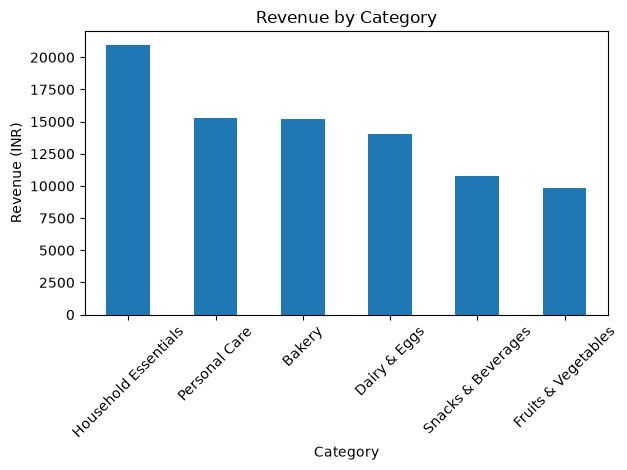

In [23]:
cat.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
sup = df[df["status"] == "Delivered"].groupby("supplier")["amount_inr"].sum().sort_values(ascending=False)

print(sup)
print("Top supplier:", sup.index[0])
print("Top revenue:", sup.iloc[0])

supplier
HomeEssentials Traders    20968.0
BakeHouse Supplies        18811.5
CarePlus Distributors     15291.5
DairyBest Ltd             10876.5
SnackHub India             7185.0
FreshFarms Co              5490.0
GreenValley Traders        4361.5
CountryEggs Farms          3131.5
Name: amount_inr, dtype: float64
Top supplier: HomeEssentials Traders
Top revenue: 20968.0


In [25]:
sql = pd.read_csv("monthly_category_revenue.csv")

sql_cat = sql.groupby("category")["total_revenue"].sum().sort_values(ascending=False)

print(sql_cat)
print("SQL top category:", sql_cat.index[0])
print("Python top category:", cat.index[0])

category
Household Essentials    21715
Personal Care           16382
Bakery                  15410
Dairy & Eggs            14090
Snacks & Beverages      10895
Fruits & Vegetables      9790
Name: total_revenue, dtype: int64
SQL top category: Household Essentials
Python top category: Household Essentials


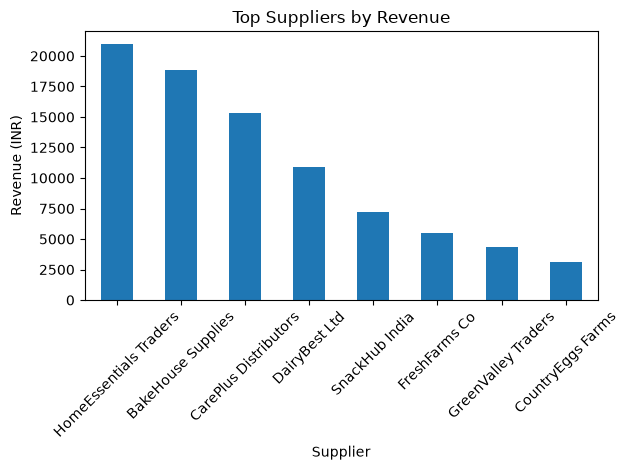

In [26]:
sup.head(10).plot(kind="bar")

plt.title("Top Suppliers by Revenue")
plt.xlabel("Supplier")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
print("Top category:", cat.index[0])
print("Top category revenue:", cat.iloc[0])

print("Top supplier:", sup.index[0])
print("Top supplier revenue:", sup.iloc[0])

Top category: Household Essentials
Top category revenue: 20968.0
Top supplier: HomeEssentials Traders
Top supplier revenue: 20968.0


In [28]:
print("Final rows:", len(df))
print("Missing amount:", df["amount_inr"].isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Final rows: 495
Missing amount: 0
Duplicate rows: 0
